# Figure 5.1 — Zero-shot failure cases (DehazeDDPM pre-train on ColdFog test)

Qualitative grid for **official DENSE / NH checkpoints** evaluated zero-shot on the 80-image ColdFog test split.

| Column | Content |
|--------|---------|
| Failure mode | Row label (text only) |
| Hazy input | Saved `_lr.png` from inference (network input, 448×576) |
| DENSE output | `0_{idx}_out.png` from DENSE pre-train run |
| NH output | `0_{idx}_out.png` from NH pre-train run |
| Ground truth | `gt_test` resized to match `_lr` |

**Index convention:** `idx` is **1-based**, matching `infer.py` output names and `plot/test_metadata.json` → `samples[].index`.

Edit `FAIL_CASES` below to swap representative scenes after visual review.

The last cell exports:
- **12 panel images** (3 failure rows × 4 columns) to `output/panels/`, named  
  `r{row}_{mode-slug}_idx{index}_{hazy|dense|nh|gt}.png`
- **3 row strips** (one 1×4 image per failure case, no text) to `output/rows/`, named  
  `r{row}_{mode-slug}_idx{index}_row.png`

In [13]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

TEXTWIDTH_IN = 5.768

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

ROOT = Path("/mnt/newdisk/Documents/linzhanyang/DehazeDDPM")
PLOT_DIR = ROOT / "plot" / "ch5_zero_shot_failure_cases"
METADATA_PATH = ROOT / "plot" / "test_metadata.json"
FOGGY_METRICS_PATH = ROOT / "plot" / "data" / "foggy_input_metrics_cache.json"

EXP_DENSE = ROOT / (
    "experiments/test/pretrain_model_domain_gap/"
    "Dehaze_ColdFog_pretrain_test_DENSE_ddim100_260526_110402"
)
EXP_NH = ROOT / (
    "experiments/test/pretrain_model_domain_gap/"
    "Dehaze_ColdFog_pretrain_test_NH_ddim100_260526_111436"
)
PATH_DENSE = EXP_DENSE / "results"
PATH_NH = EXP_NH / "results"
PATH_DENSE_METRICS = EXP_DENSE / "logs" / "per_image_metrics.json"
PATH_NH_METRICS = EXP_NH / "logs" / "per_image_metrics.json"

INFER_SAVE_STEP = 0
OUT_DIR = PLOT_DIR / "output"
OUT_PANELS_DIR = OUT_DIR / "panels"  # 12 single images: 3 rows × 4 columns
OUT_ROWS_DIR = OUT_DIR / "rows"      # 3 row strips: 1×4 images, no text
ROW_GAP_PX = 12                       # white gap between panels in row strips

In [14]:
def load_metadata(path: Path) -> tuple[dict, dict[int, dict]]:
    meta = json.loads(path.read_text(encoding="utf-8"))
    by_index = {s["index"]: s for s in meta["samples"]}
    return meta, by_index


def load_rgb(path: Path) -> np.ndarray:
    return np.asarray(Image.open(path).convert("RGB"))


def load_gt_matched_to_lr(gt_path: Path, lr_hw: tuple[int, int]) -> np.ndarray:
    h, w = lr_hw
    im = Image.open(gt_path).convert("RGB").resize((w, h), Image.LANCZOS)
    return np.asarray(im)


def infer_paths(idx: int, results_dir: Path, infer_step: int = INFER_SAVE_STEP) -> tuple[Path, Path]:
    return (
        results_dir / f"{infer_step}_{idx}_lr.png",
        results_dir / f"{infer_step}_{idx}_out.png",
    )


meta, index_to_sample = load_metadata(METADATA_PATH)
GT_ROOT = Path(meta["dataroothq"])
HAZY_ROOT = Path(meta["datarootlq"])

print(f"Dataset: {meta['dataset_name']}  |  n={meta['count']}")
print(f"GT root: {GT_ROOT}")
print(f"DENSE results: {PATH_DENSE}")
print(f"NH results:    {PATH_NH}")

Dataset: Cold Storage Dehazing Dataset  |  n=80
GT root: /mnt/newdisk/Documents/linzhanyang/data/dehazeddpm_test/gt_test
DENSE results: /mnt/newdisk/Documents/linzhanyang/DehazeDDPM/experiments/test/pretrain_model_domain_gap/Dehaze_ColdFog_pretrain_test_DENSE_ddim100_260526_110402/results
NH results:    /mnt/newdisk/Documents/linzhanyang/DehazeDDPM/experiments/test/pretrain_model_domain_gap/Dehaze_ColdFog_pretrain_test_NH_ddim100_260526_111436/results


In [15]:
def load_metrics_by_index(path: Path) -> dict[int, dict]:
    data = json.loads(path.read_text(encoding="utf-8"))
    return {row["index"]: row for row in data["per_image"]}


def summarize_case(idx: int) -> dict:
    sample = index_to_sample[idx]
    foggy = load_metrics_by_index(FOGGY_METRICS_PATH)[idx]
    dense = load_metrics_by_index(PATH_DENSE_METRICS)[idx]
    nh = load_metrics_by_index(PATH_NH_METRICS)[idx]
    return {
        "index": idx,
        "filename": sample["filename"],
        "fog_level": sample["fog_level"],
        "psnr_fog": foggy["psnr"],
        "psnr_dense": dense["psnr"],
        "psnr_nh": nh["psnr"],
        "delta_dense": dense["psnr"] - foggy["psnr"],
        "delta_nh": nh["psnr"] - foggy["psnr"],
        "ssim_dense": dense["ssim"],
        "ssim_nh": nh["ssim"],
    }


def rank_light_overprocessing(top_k: int = 8) -> list[dict]:
    rows = [summarize_case(i) for i in range(1, meta["count"] + 1)]
    low = [r for r in rows if r["fog_level"] == "low" and (r["delta_dense"] < 0 or r["delta_nh"] < 0)]
    return sorted(low, key=lambda r: min(r["delta_dense"], r["delta_nh"]))[:top_k]


def rank_heavy_residual(top_k: int = 8) -> list[dict]:
    rows = [summarize_case(i) for i in range(1, meta["count"] + 1)]
    heavy = [r for r in rows if r["fog_level"] == "heavy"]
    return sorted(heavy, key=lambda r: min(r["psnr_dense"], r["psnr_nh"]))[:top_k]


def rank_low_texture_artifacts(top_k: int = 8) -> list[dict]:
    rows = [summarize_case(i) for i in range(1, meta["count"] + 1)]
    return sorted(rows, key=lambda r: min(r["ssim_dense"], r["ssim_nh"]))[:top_k]


def print_rank(title: str, rows: list[dict]) -> None:
    print(title)
    for r in rows:
        print(
            f"  idx={r['index']:2d} {r['fog_level']:6s} {r['filename'][:34]:34s} "
            f"fog={r['psnr_fog']:5.1f} D={r['psnr_dense']:5.1f}({r['delta_dense']:+.1f}) "
            f"NH={r['psnr_nh']:5.1f}({r['delta_nh']:+.1f}) "
            f"ssim_D={r['ssim_dense']:.2f} ssim_NH={r['ssim_nh']:.2f}"
        )


print_rank("Light over-processing (low fog, dehaze worse than fog):", rank_light_overprocessing())
print()
print_rank("Heavy residual haze (heavy fog, low output PSNR):", rank_heavy_residual())
print()
print_rank("Low SSIM candidates (verify visually for reflective / low-texture):", rank_low_texture_artifacts())

Light over-processing (low fog, dehaze worse than fog):
  idx=17 low    sdm_20260210_0243_low.png          fog= 27.4 D= 18.6(-8.9) NH= 13.5(-13.9) ssim_D=0.48 ssim_NH=0.43
  idx= 9 low    ggl_20260202_0076_low.jpg          fog= 28.4 D= 17.6(-10.8) NH= 15.8(-12.6) ssim_D=0.62 ssim_NH=0.87
  idx=18 low    ggl_20260202_0118_low.jpg          fog= 23.0 D= 20.3(-2.7) NH= 12.4(-10.6) ssim_D=0.69 ssim_NH=0.47
  idx=12 low    sdm_20260212_0267_low.png          fog= 26.4 D= 16.3(-10.1) NH= 18.9(-7.5) ssim_D=0.60 ssim_NH=0.42
  idx=45 low    ggl_20260202_0031_low.jpg          fog= 21.6 D= 21.1(-0.5) NH= 12.8(-8.7) ssim_D=0.62 ssim_NH=0.48
  idx=41 low    sdm_20260204_0206_low.jpg          fog= 23.4 D= 17.9(-5.5) NH= 15.1(-8.4) ssim_D=0.65 ssim_NH=0.60
  idx=61 low    ggl_20260202_0004_low.jpg          fog= 22.5 D= 16.4(-6.2) NH= 14.3(-8.2) ssim_D=0.47 ssim_NH=0.37
  idx=53 low    sdm_20260212_0277_low.jpg          fog= 20.0 D= 13.3(-6.7) NH= 15.9(-4.1) ssim_D=0.57 ssim_NH=0.70

Heavy residual haz

In [16]:
# Edit indices after visual review. Defaults follow metric shortlist from pre-run screening.
FAIL_CASES = [
    {
        "mode": "Light over-processing",
        "index": 14,
        "note": "ggl_20260202_0076_low.jpg — strong PSNR drop on thin fog",
    },
    {
        "mode": "Heavy residual haze",
        "index": 62,
        "note": "sdm_20260210_0256_heavy.png — near-zero gain, low SSIM",
    },
    {
        "mode": "Reflective / low-texture artifact",
        "index": 43,
        "note": "sdm_20260210_0254_heavy.png — replace if a clearer reflective case is found",
    },
]

for case in FAIL_CASES:
    idx = case["index"]
    s = index_to_sample[idx]
    lr_d, out_d = infer_paths(idx, PATH_DENSE)
    lr_n, out_n = infer_paths(idx, PATH_NH)
    gt = GT_ROOT / s["filename"]
    missing = [p.name for p in (lr_d, out_d, lr_n, out_n, gt) if not p.is_file()]
    status = "OK" if not missing else f"MISSING: {missing}"
    print(f"[{case['mode']}] idx={idx} {s['filename']} ({s['fog_level']}) — {status}")
    print(f"  {case['note']}")
    m = summarize_case(idx)
    print(
        f"  PSNR fog={m['psnr_fog']:.1f}  D={m['psnr_dense']:.1f}  NH={m['psnr_nh']:.1f}  "
        f"SSIM D={m['ssim_dense']:.2f} NH={m['ssim_nh']:.2f}"
    )

[Light over-processing] idx=14 ggl_20260202_0056_low.jpg (low) — OK
  ggl_20260202_0076_low.jpg — strong PSNR drop on thin fog
  PSNR fog=17.6  D=16.6  NH=18.8  SSIM D=0.66 NH=0.81
[Heavy residual haze] idx=62 ggl_20260204_0152_heavy.jpg (heavy) — OK
  sdm_20260210_0256_heavy.png — near-zero gain, low SSIM
  PSNR fog=7.4  D=14.8  NH=12.7  SSIM D=0.63 NH=0.51
[Reflective / low-texture artifact] idx=43 ggl_20260202_0091_medium.jpg (medium) — OK
  sdm_20260210_0254_heavy.png — replace if a clearer reflective case is found
  PSNR fog=11.5  D=14.3  NH=14.7  SSIM D=0.49 NH=0.39


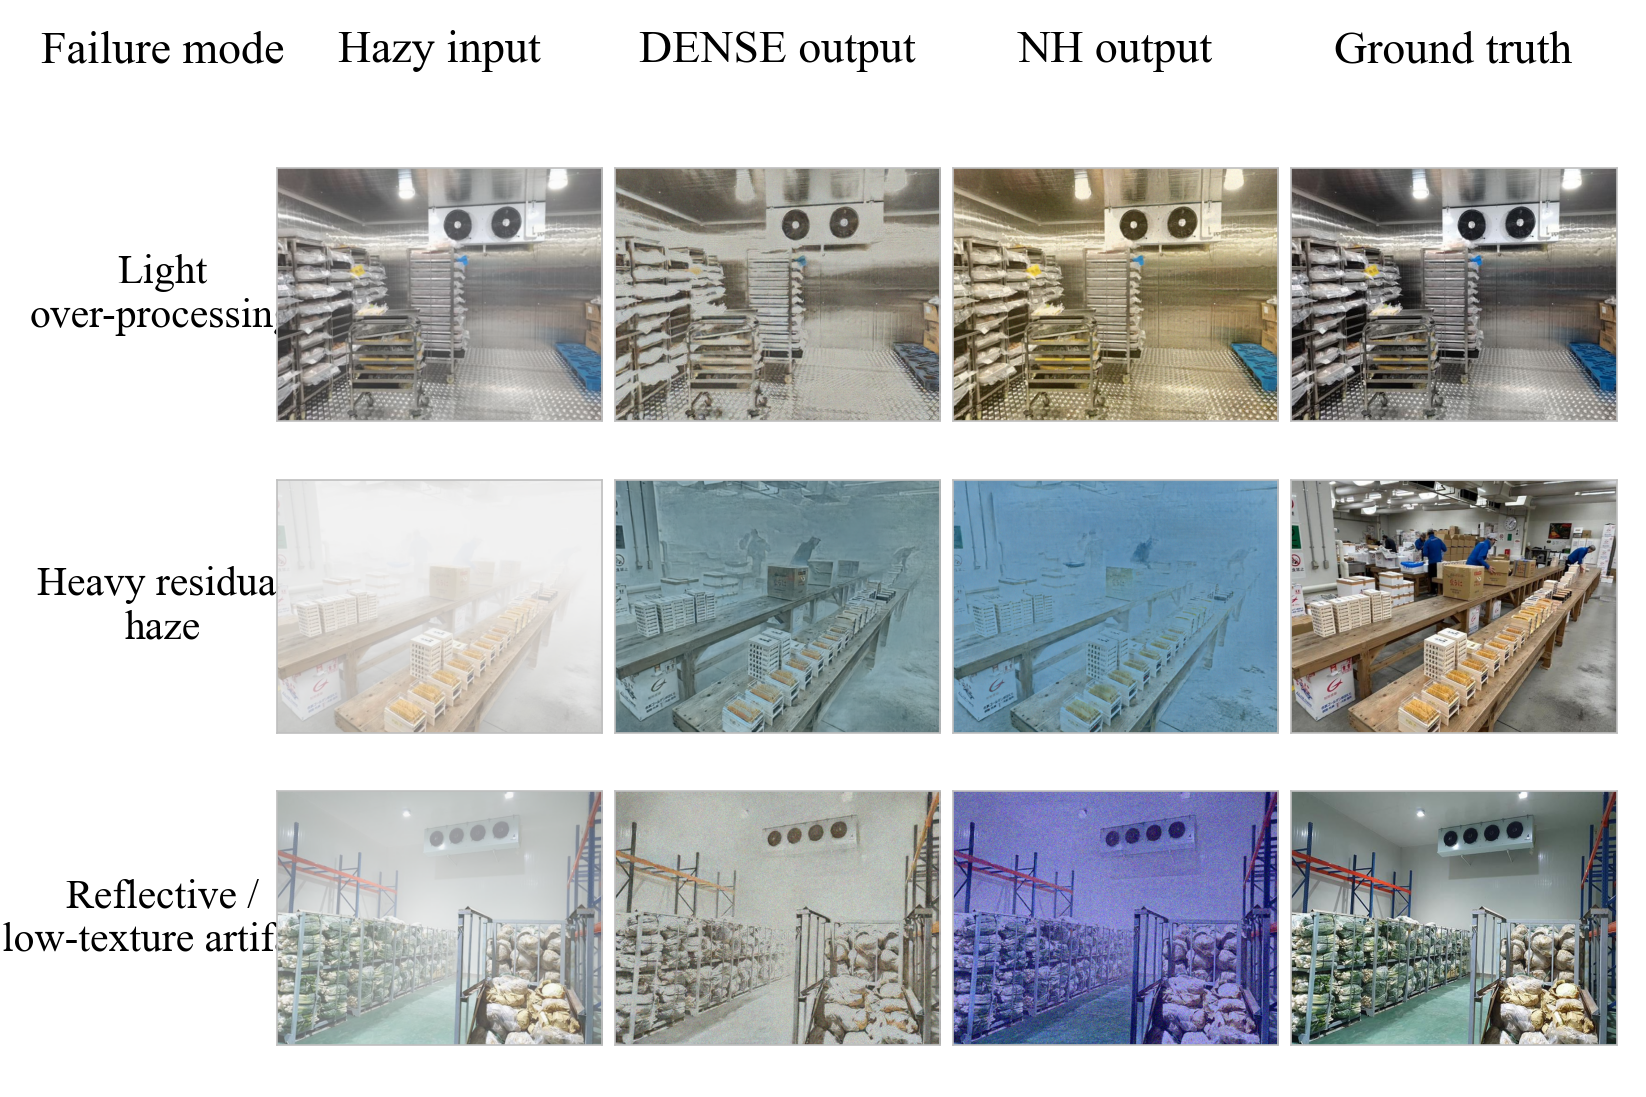

In [17]:
import re

COL_TITLES = ["Hazy input", "DENSE output", "NH output", "Ground truth"]
PANEL_SPECS = [
    ("hazy", "Hazy input"),
    ("dense", "DENSE output"),
    ("nh", "NH output"),
    ("gt", "Ground truth"),
]
MODE_COL_WIDTH = 0.72  # inches, text-only column
IMG_COL_WIDTH = 1.15   # inches per image column


def mode_slug(mode: str) -> str:
    """Filesystem-safe tag from failure-mode label (supports \\n in mode)."""
    s = mode.replace("\n", " ")
    s = re.sub(r"[^a-zA-Z0-9]+", "-", s.strip().lower())
    return s.strip("-") or "case"


def collect_case_panels(case: dict) -> dict[str, np.ndarray]:
    idx = case["index"]
    sample = index_to_sample[idx]
    lr_d, out_d = infer_paths(idx, PATH_DENSE)
    _, out_n = infer_paths(idx, PATH_NH)
    gt_path = GT_ROOT / sample["filename"]
    fog = load_rgb(lr_d)
    gt = load_gt_matched_to_lr(gt_path, fog.shape[:2])
    return {
        "hazy": fog,
        "dense": load_rgb(out_d),
        "nh": load_rgb(out_n),
        "gt": gt,
    }


def save_failure_panels(
    cases: list[dict],
    out_dir: Path,
    *,
    formats: tuple[str, ...] = ("png",),
) -> list[Path]:
    """Save 3×4=12 panels. Name: r{row}_{mode-slug}_idx{idx}_{col}.png"""
    out_dir.mkdir(parents=True, exist_ok=True)
    saved: list[Path] = []
    for row, case in enumerate(cases, start=1):
        slug = mode_slug(case["mode"])
        idx = case["index"]
        panels = collect_case_panels(case)
        stem = f"r{row:02d}_{slug}_idx{idx:03d}"
        for col_key, _title in PANEL_SPECS:
            img = panels[col_key]
            for ext in formats:
                path = out_dir / f"{stem}_{col_key}.{ext}"
                if ext == "png":
                    Image.fromarray(img).save(path, format="PNG")
                elif ext in ("jpg", "jpeg"):
                    Image.fromarray(img).save(path, format="JPEG", quality=95)
                else:
                    raise ValueError(f"unsupported format: {ext}")
                saved.append(path)
    return saved


def save_failure_rows(
    cases: list[dict],
    out_dir: Path,
    *,
    formats: tuple[str, ...] = ("png",),
    gap_px: int = ROW_GAP_PX,
) -> list[Path]:
    """Save one 1×4 strip per case (hazy | dense | nh | gt), no text."""
    out_dir.mkdir(parents=True, exist_ok=True)
    col_keys = [k for k, _ in PANEL_SPECS]
    saved: list[Path] = []
    for row, case in enumerate(cases, start=1):
        slug = mode_slug(case["mode"])
        idx = case["index"]
        panels = collect_case_panels(case)
        imgs = [Image.fromarray(panels[k]) for k in col_keys]
        w, h = imgs[0].size
        for im in imgs[1:]:
            if im.size != (w, h):
                raise ValueError(
                    f"panel size mismatch for idx {idx}: expected {(w, h)}, got {im.size}"
                )

        total_w = len(imgs) * w + gap_px * max(0, len(imgs) - 1)
        strip = Image.new("RGB", (total_w, h), color=(255, 255, 255))
        x = 0
        for i, im in enumerate(imgs):
            strip.paste(im, (x, 0))
            x += w + (gap_px if i < len(imgs) - 1 else 0)

        stem = f"r{row:02d}_{slug}_idx{idx:03d}_row"
        for ext in formats:
            path = out_dir / f"{stem}.{ext}"
            if ext == "png":
                strip.save(path, format="PNG")
            elif ext in ("jpg", "jpeg"):
                strip.save(path, format="JPEG", quality=95)
            else:
                raise ValueError(f"unsupported format: {ext}")
            saved.append(path)
    return saved


def show_failure_grid(
    cases: list[dict],
    *,
    save_path: Path | None = None,
    show_caption: bool = True,
) -> plt.Figure:
    n = len(cases)
    first_idx = cases[0]["index"]
    lr_path, _ = infer_paths(first_idx, PATH_DENSE)
    fog0 = load_rgb(lr_path)
    img_aspect = fog0.shape[0] / fog0.shape[1]

    fig_width = MODE_COL_WIDTH + 4 * IMG_COL_WIDTH
    row_height = IMG_COL_WIDTH * img_aspect
    caption_h = 0.55 if show_caption else 0.0
    fig_height = 0.25 + n * row_height + 0.35 + caption_h

    fig = plt.figure(figsize=(fig_width, fig_height))
    width_ratios = [MODE_COL_WIDTH / IMG_COL_WIDTH, 1, 1, 1, 1]
    gs = fig.add_gridspec(
        n + 1,
        5,
        height_ratios=[0.18] + [1.0] * n,
        width_ratios=width_ratios,
        wspace=0.04,
        hspace=0.06,
        left=0.02,
        right=0.995,
        top=0.94,
        bottom=0.08 if show_caption else 0.04,
    )

    ax_mode_hdr = fig.add_subplot(gs[0, 0])
    ax_mode_hdr.set_title("Failure mode", fontsize=11, pad=4)
    ax_mode_hdr.axis("off")
    for c, title in enumerate(COL_TITLES, start=1):
        ax_title = fig.add_subplot(gs[0, c])
        ax_title.set_title(title, fontsize=11, pad=4)
        ax_title.axis("off")

    for r, case in enumerate(cases):
        idx = case["index"]
        sample = index_to_sample[idx]
        lr_d, out_d = infer_paths(idx, PATH_DENSE)
        _, out_n = infer_paths(idx, PATH_NH)
        gt_path = GT_ROOT / sample["filename"]

        fog = load_rgb(lr_d)
        gt = load_gt_matched_to_lr(gt_path, fog.shape[:2])

        ax_mode = fig.add_subplot(gs[r + 1, 0])
        ax_mode.axis("off")
        ax_mode.text(
            0.5,
            0.5,
            case["mode"],
            ha="center",
            va="center",
            fontsize=10,
            wrap=True,
        )

        images = [
            fog,
            load_rgb(out_d),
            load_rgb(out_n),
            gt,
        ]
        for c, img in enumerate(images, start=1):
            ax = fig.add_subplot(gs[r + 1, c])
            ax.imshow(img)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_linewidth(0.4)
                spine.set_color("0.75")

    # if show_caption:
        # fig.text(
        #     0.5,
        #     0.02,
        #     "Figure 5.1  Representative zero-shot failure cases of official DehazeDDPM checkpoints "
        #     "on cold-storage fog images (DDIM-100). "
        #     "Examples illustrate light-fog over-processing, residual haze under stronger fog, "
        #     "and artifacts in low-texture or reflective regions.",
        #     ha="center",
        #     va="bottom",
        #     fontsize=9,
        #     wrap=True,
        # )

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight", pad_inches=0.02)
        print(f"Saved: {save_path}")

    return fig


fig = show_failure_grid(FAIL_CASES)
plt.show()

In [18]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PANELS_DIR.mkdir(parents=True, exist_ok=True)
OUT_ROWS_DIR.mkdir(parents=True, exist_ok=True)

saved_paths = save_failure_panels(FAIL_CASES, OUT_PANELS_DIR, formats=("png",))
print(f"Saved {len(saved_paths)} panels → {OUT_PANELS_DIR}\n")
for p in saved_paths:
    print(f"  {p.name}")

saved_rows = save_failure_rows(FAIL_CASES, OUT_ROWS_DIR, formats=("png",))
print(f"\nSaved {len(saved_rows)} row strips → {OUT_ROWS_DIR}\n")
for p in saved_rows:
    print(f"  {p.name}")

# Optional: full composite figure (uncomment to export)
# show_failure_grid(
#     FAIL_CASES,
#     save_path=OUT_DIR / "figure_5_1_zero_shot_failures.pdf",
#     show_caption=False,
# )
# show_failure_grid(
#     FAIL_CASES,
#     save_path=OUT_DIR / "figure_5_1_zero_shot_failures.png",
#     show_caption=False,
# )
plt.close("all")

Saved 12 panels → /mnt/newdisk/Documents/linzhanyang/DehazeDDPM/plot/ch5_zero_shot_failure_cases/output/panels

  r01_light-over-processing_idx014_hazy.png
  r01_light-over-processing_idx014_dense.png
  r01_light-over-processing_idx014_nh.png
  r01_light-over-processing_idx014_gt.png
  r02_heavy-residual-haze_idx062_hazy.png
  r02_heavy-residual-haze_idx062_dense.png
  r02_heavy-residual-haze_idx062_nh.png
  r02_heavy-residual-haze_idx062_gt.png
  r03_reflective-low-texture-artifact_idx043_hazy.png
  r03_reflective-low-texture-artifact_idx043_dense.png
  r03_reflective-low-texture-artifact_idx043_nh.png
  r03_reflective-low-texture-artifact_idx043_gt.png

Saved 3 row strips → /mnt/newdisk/Documents/linzhanyang/DehazeDDPM/plot/ch5_zero_shot_failure_cases/output/rows

  r01_light-over-processing_idx014_row.png
  r02_heavy-residual-haze_idx062_row.png
  r03_reflective-low-texture-artifact_idx043_row.png
